In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from csv_reader import read_csv
from copy import deepcopy as copy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_PAIRWISE_RULES_PER_TYPE = 12 * 2
N_SUMMED_WEIGHT_RULES_PER_TYPE = 4
N_THREE_FACTOR_RULES_PER_TYPE = 8
N_RULES = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE) + 2 * N_THREE_FACTOR_RULES_PER_TYPE

CELL_TYPE_1_SIZE = 5

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS_NO_HET_SHORT = [
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244677_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244680_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244675_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244675_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244680_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:23.174955_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:23.174963_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:30.925336_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:19:03.672463_run_None',
]

DATA_PATHS_NO_HET_LONG = [
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:05.556906_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:15.419305_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:26.546887_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447171_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447169_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:26.630956_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:29.091066_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:29.091061_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:13.447167_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:43.001674_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:42.975309_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:17:43.009313_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-17_00:18:50.244672_run_None',
]

DATA_PATHS_NO_HET_SHORT_DROP_Z = [
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:40.453833_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:40.479882_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:39:37.864984_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:40:12.423111_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:40:36.158512_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:41:06.670440_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:41:37.489542_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:42:08.757776_run_None',
    'sims_out/rule_dropout_z_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:42:39.625754_run_None',
]

DATA_PATHS_NO_HET_LONG_DROP_Z = [
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:32:01.722941_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:32:12.629517_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:07.546528_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:09.033664_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:33:03.666116_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:35:39.951326_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:35:39.951334_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168738_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168743_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:36:14.168742_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:37:04.286858_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:05.257031_run_None',
    'sims_out/rule_dropout_z_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-02-20_11:38:07.097905_run_None',
]

rules_to_dropout = np.concatenate([
    np.arange(N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
    np.arange(
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)
        + N_THREE_FACTOR_RULES_PER_TYPE,
    ),
])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\Sigma_k w_{kj}$',
    r'$w \Sigma_k w_{kj}$',
	r'$\Sigma_k w_{ik}$',
    r'$w \Sigma_k w_{ik}$',
]

# rule_names = [
# 	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
# 	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
# 	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
# ]

rule_names = [
	rule_names,
    rule_names,
    rule_names,
]

rule_names_tripartite = [
	r'$\tilde{y} \tilde{z}$',
    r'$x \tilde{y} \tilde{z}$',
	r'$\tilde{x} \tilde{z}$',
	r'$\tilde{x} y \tilde{z}$',

	r'$w \tilde{y} \tilde{z}$',
    r'$w x \tilde{y} \tilde{z}$',
	r'$w \tilde{x} \tilde{z}$',
	r'$w \tilde{x} y \tilde{z}$',
]

rule_names += [
	[r_name for r_name in rule_names_tripartite],
	[r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)

In [7]:
print(rule_names)

['' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$' '$y^4$' '$x^4$'
 '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$' '$w$' '$w y$'
 '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$' '$w x^4$'
 '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$' '$\\Sigma_k w_{ik}$'
 '$w \\Sigma_k w_{ik}$' '' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$'
 '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$'
 '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$'
 '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$' '$\\Sigma_k w_{ik}$'
 '$w \\Sigma_k w_{ik}$' '' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$'
 '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$'
 '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$'
 '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma

In [8]:
def load_coefs(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)
    coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_RULES])
    return coefs

def load_all_coefs(dfs):
    return np.asarray([
        load_coefs(df)
        for df in dfs
    ])

def load_losses(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)

    losses = np.array(o.iloc[:, 1])
    return losses

def make_loss_plots(dfs, num_terms=36, vmax=500):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_losses(df)
        
        if len(losses) < 30 * (num_terms + 1):
            continue
            
        losses_for_term_dropouts = []
        for i in range(num_terms + 1):
            losses_for_term_dropouts.append(losses[30 * i: 30 * (i+1)])
        all_losses.append(losses_for_term_dropouts)

        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_losses = np.array(all_losses)
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(3, 1))
    for i in range(all_losses.shape[0]):
        axs.scatter([i] * 30, all_losses[i, 0, :], alpha=0.1)
        print(np.mean(all_losses[i, 0, :]), '+/-', np.std(all_losses[i, 0, :]))
    axs.set_ylim(0)
    axs.set_xlabel('Rule number')
    axs.set_ylabel('Loss')
    format_plot(axs)
    
    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    mat = (
        np.median(all_losses, axis=2)[:, 1:]
        - np.median(all_losses, axis=2)[:, 0][:, None]
    )
    
    sns.heatmap(
        mat.T,
        ax=ax,
        cmap='Blues',
        vmax=vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)

    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    all_coefs = all_coefs[:, rules_to_dropout]

    sns.heatmap(
        (mat * np.where(all_coefs > 0, 1, -1)).T,
        ax=ax,
        cmap=sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True),
        vmax=vmax,
        vmin=-vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )

    ctrl = np.median(all_losses, axis=2)[:, 0][:, None]

    counts_over_100 = np.where(mat > 100, 1, 0).sum(axis=1)
    print(np.mean(counts_over_100), np.std(counts_over_100))
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)

    ax.set_xticks([])

    ax.set_ylabel('Term dropped')
    ax.set_xlabel('Learned rule')
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)   

    return fig, ax

181.0903611649595 +/- 36.03229095578324
176.24009241401745 +/- 28.95143031430102
169.23429661467605 +/- 35.34634726912924
169.4472031099499 +/- 25.122244601261563
181.9084726009234 +/- 41.64056531041572
183.3181910243535 +/- 27.085122247573192
174.01665681790647 +/- 32.9028332598134
166.25175520626232 +/- 25.195083897628407
172.62209660360392 +/- 31.458684670261462
10.88888888888889 2.8846122190549264


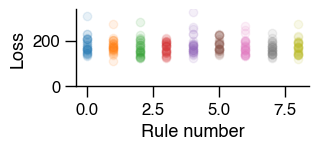

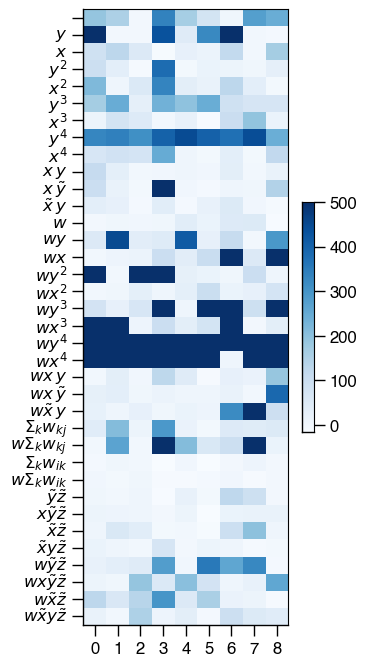

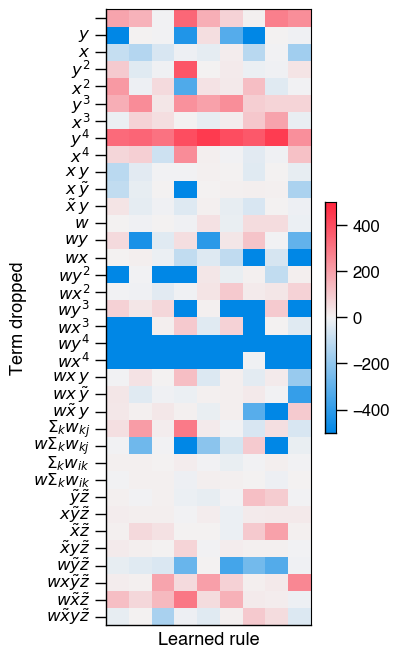

In [12]:
fig, ax = make_loss_plots(DATA_PATHS_NO_HET_SHORT, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_short.svg')

234.9803442442056 +/- 48.481536051994276
221.3074227655065 +/- 29.161463626576786
200.17647616865264 +/- 23.225448920990424
221.71907266881672 +/- 46.09450606769129
244.52136643650783 +/- 34.00045430098851
220.31081750531004 +/- 28.909108749268867
234.7428426308064 +/- 27.542594450395306
241.23427090344802 +/- 41.0953162347894
218.6959176412178 +/- 30.86912765228375
241.09275811758215 +/- 28.837998508859116
234.55575697216545 +/- 40.613610363745074
226.75727364153101 +/- 22.76130464356926
136.11885685874853 +/- 22.536588066327727
14.846153846153847 2.567433733581329


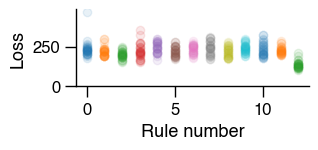

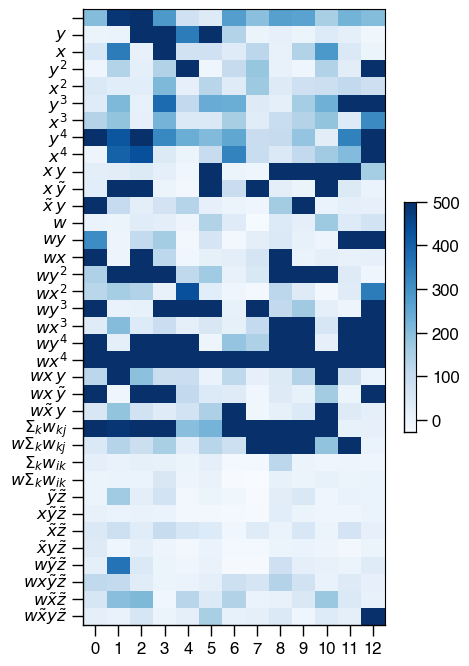

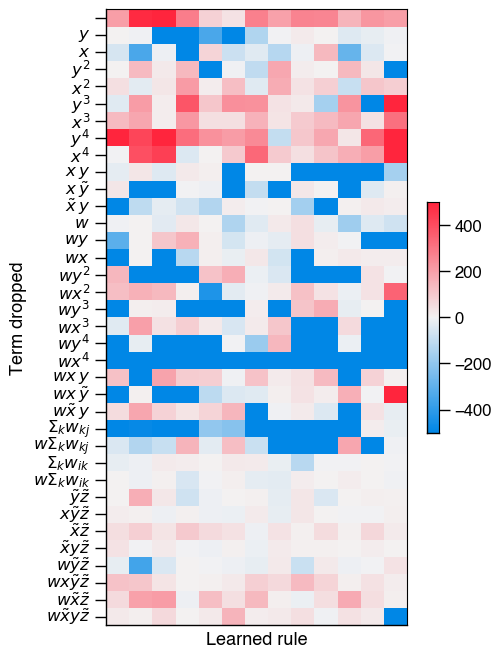

In [14]:
fig, ax = make_loss_plots(DATA_PATHS_NO_HET_LONG, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_long.svg')

In [13]:
def load_r2(df, n_nets=30):
    rule_path = Path(df) / 'scores'
    arrays = []
    arr = np.array([np.load(f) for f in rule_path.glob('ctrl/*.npy')])
    arrays.append(arr)
    for dropout_num in rules_to_dropout:
        d = zero_pad(dropout_num, 3)
        arr = np.array([np.load(f) for f in rule_path.glob(f'{d}/*.npy')])
        if len(arr) < n_nets:
            arr = np.concatenate([
                arr,
                np.zeros(n_nets - len(arr))
            ])
        arrays.append(arr)
    return arrays


def make_r2_plots(dfs, num_terms=36, vmax=1):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_r2(df)
        all_losses.append(losses)
        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(3, 1))
    for i in range(len(all_losses)):
        ctrl_losses_for_rule = all_losses[i][0]
        axs.scatter([i] * len(ctrl_losses_for_rule), ctrl_losses_for_rule, alpha=0.3, facecolor='none', edgecolor='black', s=40)
        print(np.mean(ctrl_losses_for_rule), '+/-', np.std(ctrl_losses_for_rule))
    axs.set_ylim(0, 1)
    axs.set_xlabel('Rule number')
    axs.set_ylabel(r'$R^2$')
    axs.xaxis.set_major_locator(MaxNLocator(integer=True))
    format_plot(axs)
    
    fig, ax = plt.subplots(1, 1, figsize=(0.33 * len(all_losses), 8))

    losses_medians = np.array([
        [np.median(term_losses) for term_losses in rule_losses]
        for rule_losses in all_losses
    ])

    mat = (
        losses_medians[:, 1:] - losses_medians[:, :1]
    )
    
    sns.heatmap(
        mat.T,
        ax=ax,
        cmap='Blues_r',
        vmax=0,
        vmin=-0.5,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / mat.shape[0], pad=0.06),
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)
    
    fig_r2_change_scatter, axs_r2_change_scatter = plt.subplots(1, 1, figsize=(6 * 2, 1 * 2))
    for j in range(mat.shape[1]):
         axs_r2_change_scatter.scatter([j] * mat.shape[0] , mat[:, j], alpha=0.3, facecolor='none', edgecolor='black', s=40)
    axs_r2_change_scatter.set_xticks(np.arange(num_terms))
    axs_r2_change_scatter.set_xticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=40)
    axs_r2_change_scatter.set_ylabel(r'$R^2$')
    axs_r2_change_scatter.set_xlabel('Term dropped')
    
    format_plot(axs_r2_change_scatter)

    fig, ax = plt.subplots(1, 1, figsize=(0.33 * mat.shape[0], 8))

    all_coefs = all_coefs[:, rules_to_dropout]

    sns.heatmap(
        (mat * np.where(all_coefs > 0, 1, -1)).T,
        ax=ax,
        cmap=sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True),
        vmax=vmax,
        vmin=-vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / mat.shape[0], pad=0.06),
    )

    ctrl = losses_medians[:, :1]

    counts_over_100 = np.where(mat > 0.1, 1, 0).sum(axis=1)
    print(np.mean(counts_over_100), np.std(counts_over_100))
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)

    ax.set_xticks([])

    ax.set_ylabel('Term dropped')
    ax.set_xlabel('Learned rule')
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)   

    return fig, ax

0.837182730298648 +/- 0.03479976468992772
0.82435695518489 +/- 0.028521802637486916
0.8400820944308028 +/- 0.042670105902560505
0.8459024463562239 +/- 0.02154769046033354
0.8288292741612703 +/- 0.02506637379795866
0.820525650012634 +/- 0.02990089626305565
0.8367744604298968 +/- 0.02795469874594869
0.8304407968599657 +/- 0.04115288983538924
0.8292987843732669 +/- 0.025425704116006215
0.0 0.0


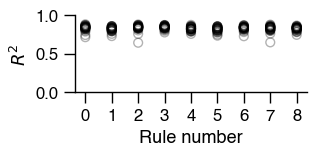

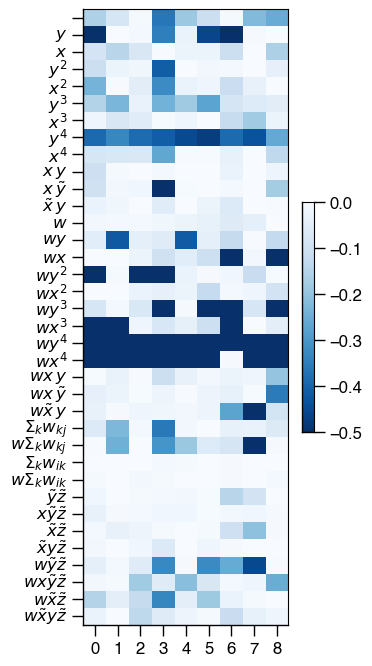

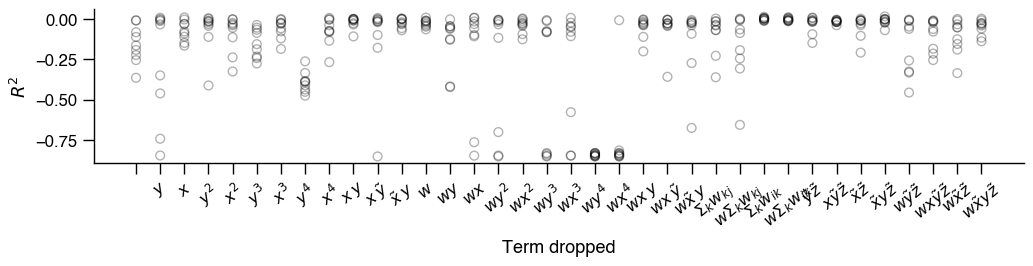

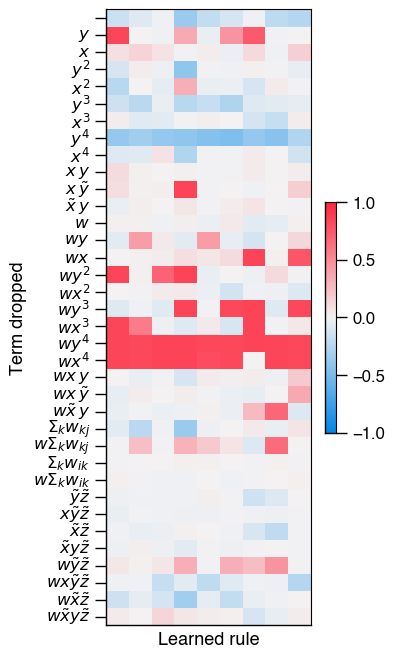

In [14]:
fig, ax = make_r2_plots(DATA_PATHS_NO_HET_SHORT, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_short_r2.svg')

0.7597902135806105 +/- 0.032267323449830125
0.7681430358463718 +/- 0.03979251113291399
0.7825744371874979 +/- 0.035562285232610326
0.7829239270185833 +/- 0.051898624919089906
0.7737670718514004 +/- 0.04005173076742025
0.7762083629113594 +/- 0.03780989494734224
0.7681959814696432 +/- 0.03980494048133533
0.7820368617957338 +/- 0.03483478165645492
0.7635411842123604 +/- 0.042019883008830236
0.7530590100069252 +/- 0.03704935156797584
0.7867636327136526 +/- 0.03269874120724726
0.766120068755083 +/- 0.03312845737540018
0.8964725405369052 +/- 0.016830413380889257
0.0 0.0


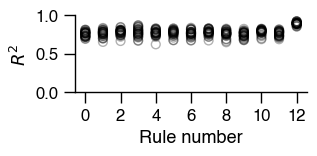

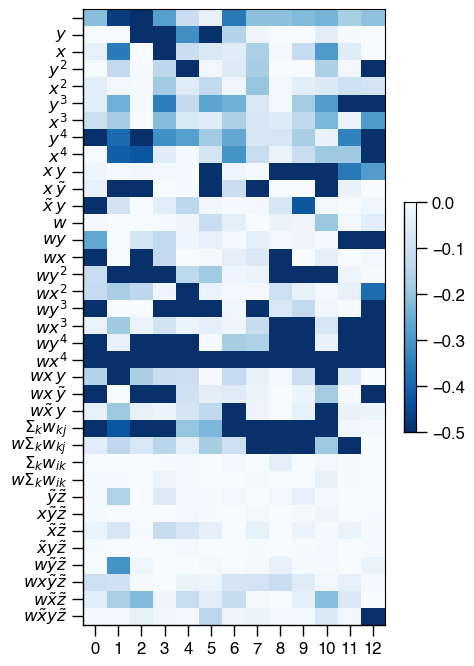

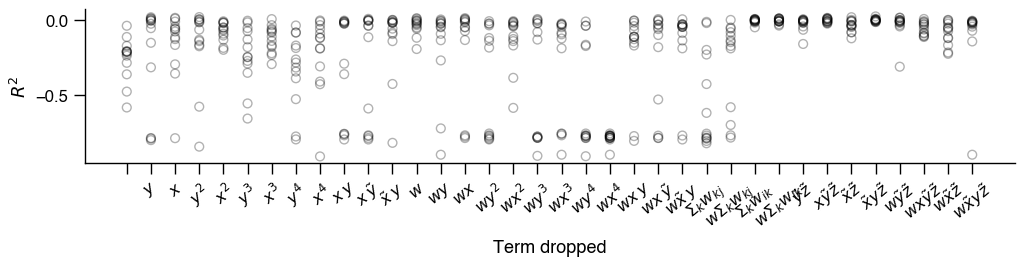

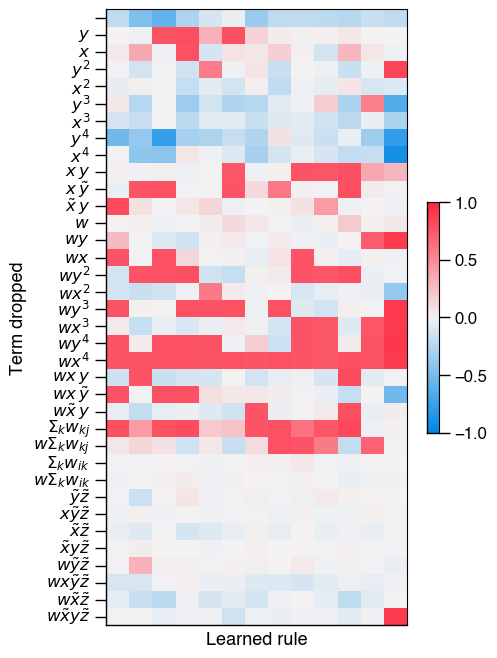

In [15]:
fig, ax = make_r2_plots(DATA_PATHS_NO_HET_LONG, num_terms=36)
fig.savefig('./figures/rule_dropouts_n5_long_r2.svg')

In [48]:
def load_r2_z(df, n_nets=30):
    rule_path = Path(df) / 'scores'
    arrays = []
    for group in ['ctrl', 'z']:
        arr = np.array([np.load(f) for f in rule_path.glob(f'{group}/*.npy')])
        if len(arr) < n_nets:
            arr = np.concatenate([
                arr,
                np.zeros(n_nets - len(arr))
            ])
        arrays.append(arr)
    return arrays


def make_r2_plots_drop_z(dfs, vmax=1):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_r2_z(df)
        all_losses.append(losses)
        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(4.5, 1))
    for i in range(len(all_losses)):
        ctrl_losses_for_rule = all_losses[i][0]
        axs.scatter([i -0.15] * len(ctrl_losses_for_rule), ctrl_losses_for_rule, alpha=0.3, facecolor='none', edgecolor='black', s=40)
        z_losses_for_rule = all_losses[i][1]
        axs.scatter([i + 0.15] * len(z_losses_for_rule), z_losses_for_rule, alpha=0.3, facecolor='none', edgecolor='red', s=40)

    axs.set_ylim(-0.3, 1)
    axs.set_xlabel('Rule number')
    axs.set_ylabel(r'$R^2$')
    axs.xaxis.set_major_locator(MaxNLocator(integer=True))
    format_plot(axs)
    return fig, axs

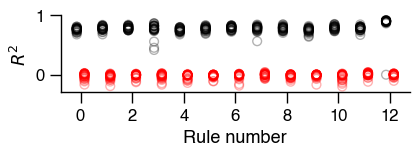

In [51]:
fig, ax = make_r2_plots_drop_z(DATA_PATHS_NO_HET_LONG_DROP_Z)
fig.savefig('./figures/rule_dropouts_n5_z_long_r2.svg')

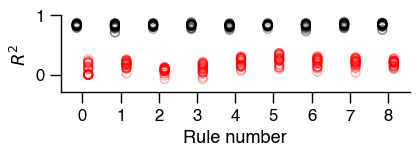

In [52]:
fig, ax = make_r2_plots_drop_z(DATA_PATHS_NO_HET_SHORT_DROP_Z)
fig.savefig('./figures/rule_dropouts_z_n5_long_r2.svg')